Galaxy and Star Classifier

# Avance 3: Baseline

## Equipo 23: Detección de Fuentes en Imágenes Astronómicas

David Adrian Guevara Gaspar-A01796618

Uriel Díaz Villamil-A01422439

Uriel Alejandro González Rojo-A01048131


In [1]:
pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.5 MB/s eta 0:00:00


In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import cv2

from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

from astroquery.skyview import SkyView
from astroquery.simbad import Simbad

from astropy.nddata import Cutout2D
import astropy.units as u
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from astropy.coordinates import SkyCoord
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.visualization.wcsaxes import SphericalCircle

In [3]:
# Usamos SIMBAD para obtener objetos cuyo otype sea Galaxy

Simbad.add_votable_fields('ra', 'dec', 'otype')

Simbad.ROW_LIMIT = 100000

crop_size = (1 * u.arcmin, 1 * u.arcmin)

galaxies_table = Simbad.query_tap("""SELECT ra, dec, main_id, otype, galdim_majaxis, galdim_minaxis
FROM basic WHERE otype = 'Galaxy' AND galdim_majaxis IS NOT NULL;""")
print(galaxies_table[['main_id','otype','galdim_majaxis', 'galdim_minaxis']])

        main_id          otype galdim_majaxis galdim_minaxis
                                   arcmin         arcmin    
------------------------ ----- -------------- --------------
WISE J042908.96-272040.0     G      0.0838355      0.0838355
            LEDA 2708079     G       0.909727       0.804744
             2MFGC 15735     G          0.337            0.1
            LEDA 1833679     G       0.460603       0.187788
            LEDA 1036669     G        0.34672       0.186847
            LEDA  472377     G       0.363633       0.213925
            LEDA  145479     G          0.392       0.301291
            LEDA  608090     G       0.245333       0.180099
SDSS J150820.35+403146.0     G      0.0621515      0.0621515
                     ...   ...            ...            ...
SDSS J142202.92+351558.3     G       0.082237       0.082237
WISE J001218.04-232816.3     G    0.054342333    0.054342333
                 IC  141     G        1.07428       0.910882
WISE J011823.05-505939.1

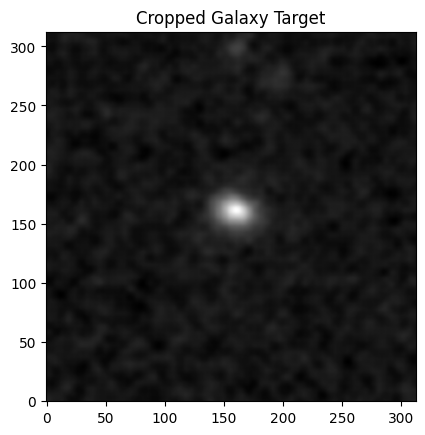

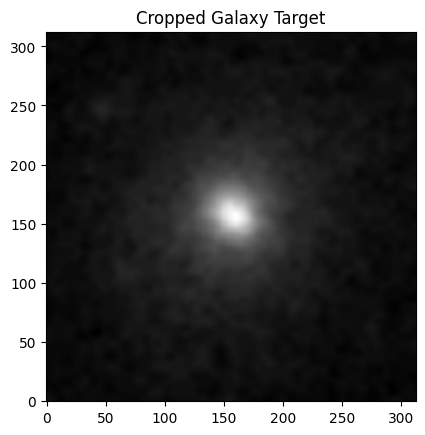

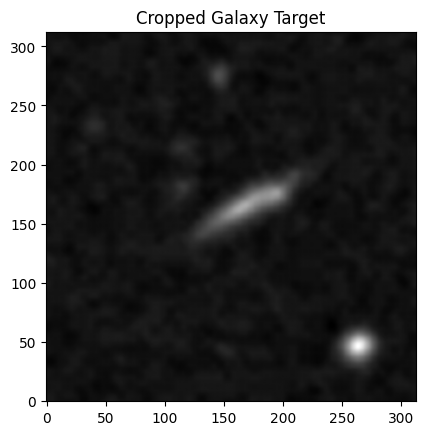

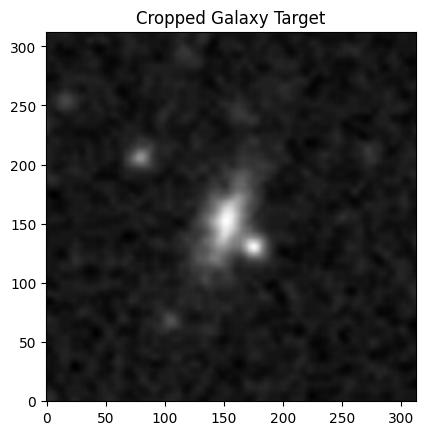

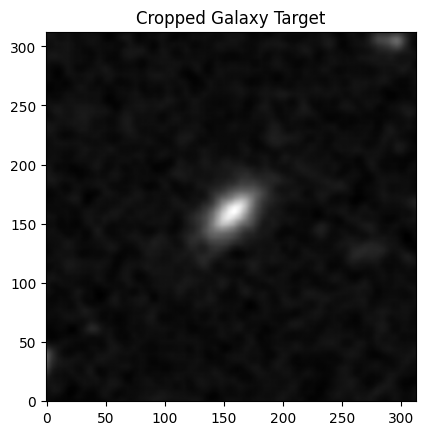

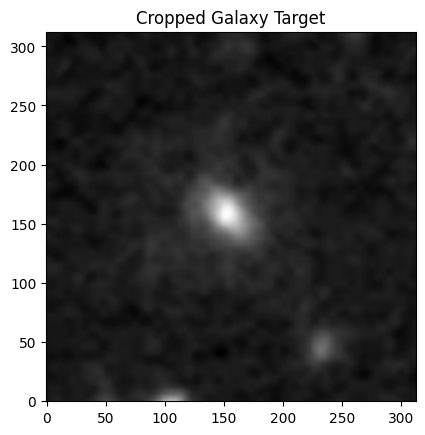

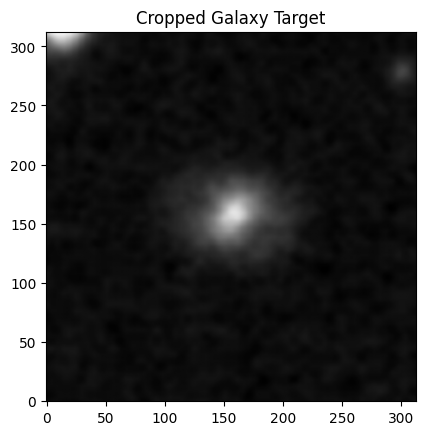

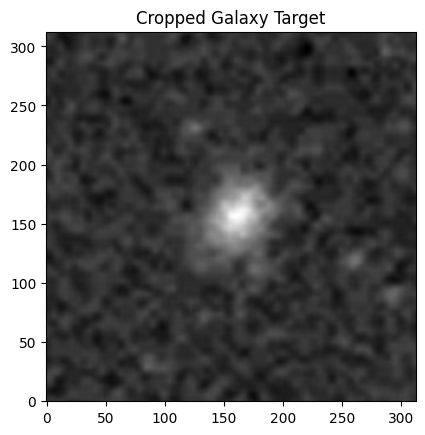

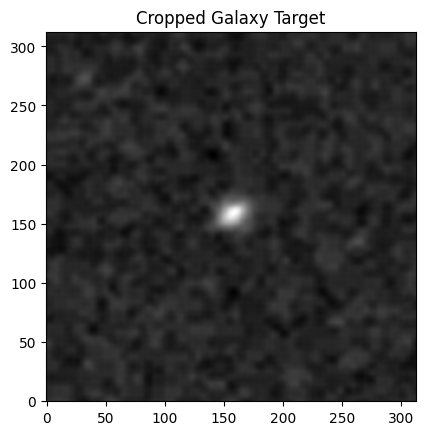

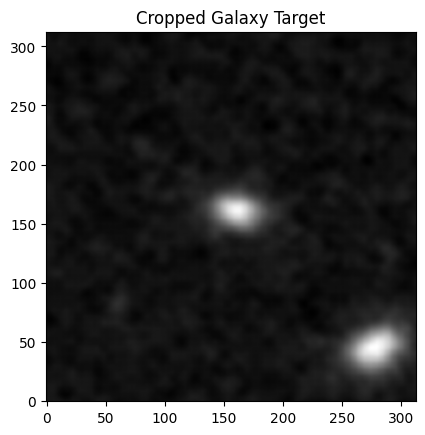

In [4]:
# Luego obtenemos las imágenes de las galaxias con SkyView

output_dir = '/content/drive/MyDrive/Proyecto Integrador/training/galaxy'
os.makedirs(output_dir, exist_ok=True)

for i, galaxy in enumerate(galaxies_table[:10]):
  ra, dec = galaxy['ra'] * u.deg, galaxy['dec'] * u.deg
  coord = SkyCoord(ra=ra, dec=dec, frame='icrs')
  paths = SkyView.get_images(position=coord, survey=['DSS2 Red'], radius=0.08 * u.deg, pixels=3000, sampler='Lanczos3')
  if not len(paths) > 0 or not len(paths[0]) > 0:
    continue
  hdu = paths[0][0]
  image_data = hdu.data
  wcs = WCS(hdu.header)

  cutout = Cutout2D(image_data, position=coord, size=crop_size, wcs=wcs)
  cutout_data = cutout.data

  plt.imshow(cutout_data, cmap='gray', origin='lower')
  plt.title('Cropped Galaxy Target')
  plt.show()
  try:
    rescaled = (255.0 / (cutout_data.max() - cutout_data.min()) * (cutout_data - cutout_data.min())).astype(np.uint8)

    im = Image.fromarray(rescaled)
    file_path = os.path.join(output_dir, f'galaxy_{i}.png')
    im.save(file_path)
  except:
    continue

In [5]:
# Ahora obtenemos los objetos tipo otype Star

stars_table = Simbad.query_tap("""SELECT ra, dec, main_id, otype
FROM basic WHERE otype = 'Star';""")
print(stars_table)

        ra                 dec                   main_id            otype
       deg                 deg                                           
------------------ ------------------- ---------------------------- -----
   161.08779769558     -58.40093790344                    HD  93189     *
 336.5461836504733   57.62486929411306 Gaia DR3 2007872029504637824     *
   348.65337281364      52.04933138078              IRAS 23123+5146     *
262.42326063662995      25.93177579119               TYC 2079-577-1     *
   299.96014442182      -4.95869196245               TYC 5155-568-1     *
    97.21166632593     -78.47322079201             UCAC4 058-004726     *
   262.51111088576      26.04038544133                TYC 2079-77-1     *
    97.21312444844     -65.56298746079                 CPD-65   606     *
    42.95892046281      33.98650624886      2MASS J02515014+3359114     *
               ...                 ...                          ...   ...
    268.4684282797      23.27734353031

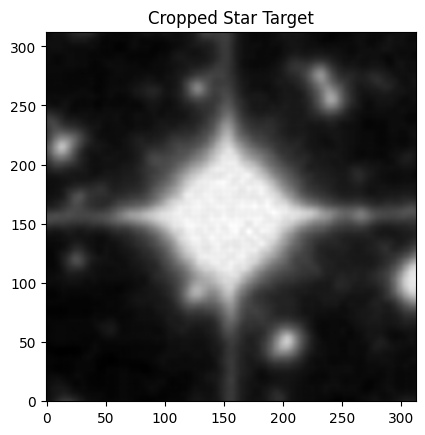

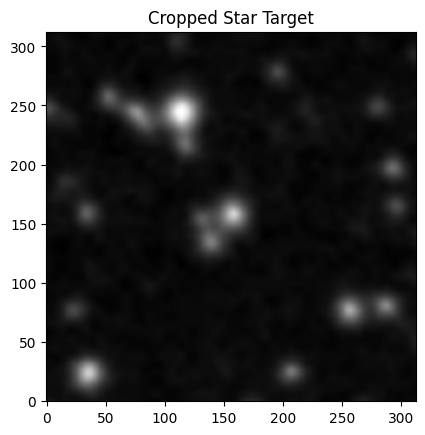

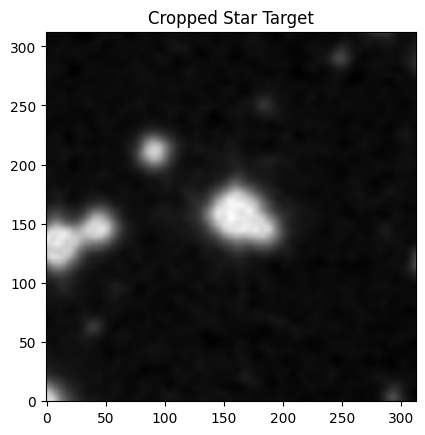

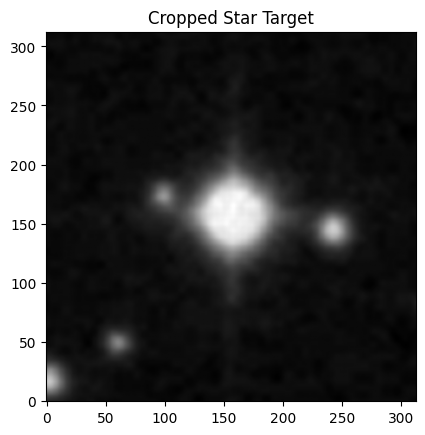

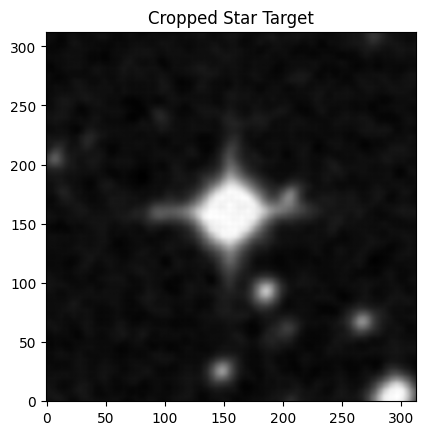

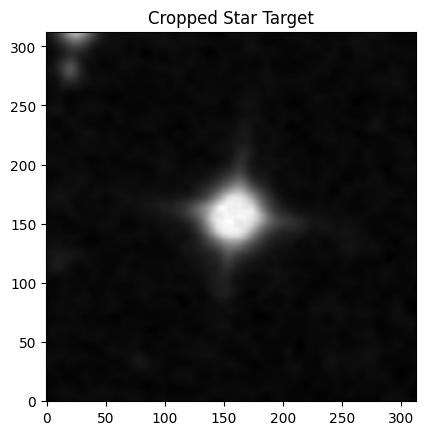

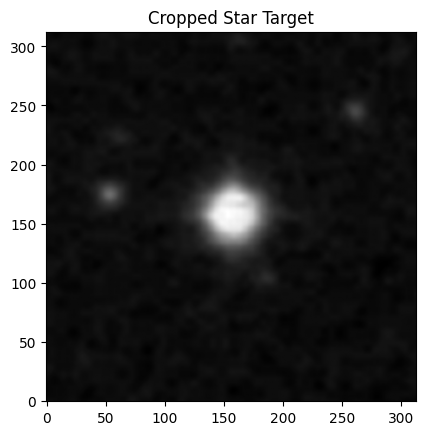

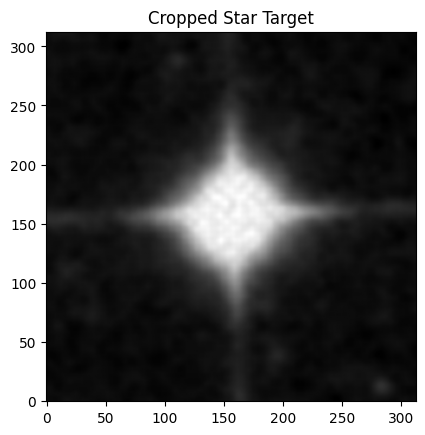

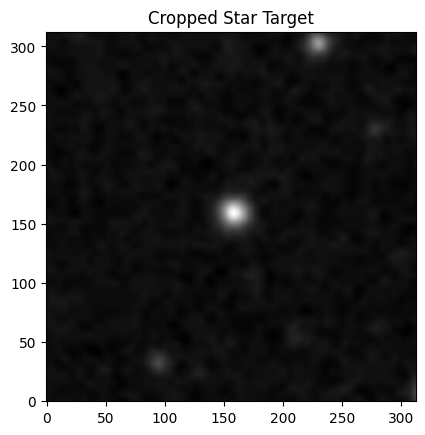

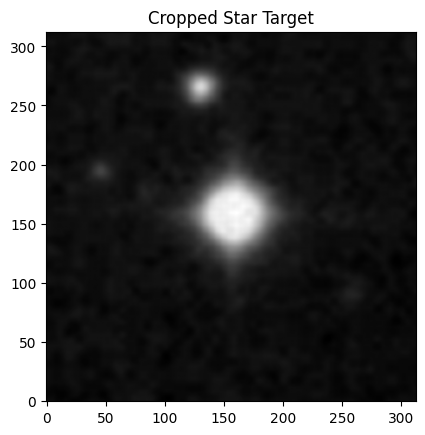

In [6]:

output_dir = '/content/drive/MyDrive/Proyecto Integrador/training/star'
os.makedirs(output_dir, exist_ok=True)

for i, star in enumerate(stars_table[:10]):
  ra, dec = star['ra'] * u.deg, star['dec'] * u.deg
  coord = SkyCoord(ra=ra, dec=dec, frame='icrs')
  paths = SkyView.get_images(position=coord, survey=['DSS2 Red'], radius=0.08 * u.deg, pixels=3000, sampler='Lanczos3')
  if not len(paths) > 0 or not len(paths[0]) > 0:
    continue
  hdu = paths[0][0]
  image_data = hdu.data
  wcs = WCS(hdu.header)

  cutout = Cutout2D(image_data, position=coord, size=crop_size, wcs=wcs)
  cutout_data = cutout.data

  plt.imshow(cutout_data, cmap='gray', origin='lower')
  plt.title('Cropped Star Target')
  plt.show()
  try:
    rescaled = (255.0 / (cutout_data.max() - cutout_data.min()) * (cutout_data - cutout_data.min())).astype(np.uint8)

    im = Image.fromarray(rescaled)
    file_path = os.path.join(output_dir, f'star_{i}.png')
    im.save(file_path)
  except:
    continue

In [12]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

torch.multiprocessing.set_start_method('spawn', force=True)

# Usar batches pequeños ayuda durante el entrenamiento

BATCH_SIZE = 16
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
NUM_CLASSES = 2  # por ahora sólo Galaxias y Estrellas
IMAGE_SIZE = (313, 313)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

TRAIN_DATA_PATH = "/content/drive/MyDrive/Proyecto Integrador/training"

if os.path.exists(TRAIN_DATA_PATH):
    full_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=train_transforms)

    train_size = int(0.8 * len(full_dataset)) # 80% entrenamiento
    val_size = len(full_dataset) - train_size # 20% validación
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    print(f"Loaded {len(train_dataset)} training images and {len(val_dataset)} validation images across {len(full_dataset.classes)} classes.")
else:
    print(f"Directory '{TRAIN_DATA_PATH}' not found. Please create it or use placeholder data.")
    dummy_data = [(torch.randn(3, *IMAGE_SIZE), torch.randint(0, NUM_CLASSES, (1,)).item()) for _ in range(128)]
    train_loader = DataLoader(dummy_data, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(dummy_data, batch_size=BATCH_SIZE, shuffle=False) # For dummy data, use the same for val

class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(GalaxyCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 78 * 78, 128),
            nn.ReLU(),
            nn.Dropout(0.5), # Usamos dropout para prevenir sobreajuste
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = GalaxyCNN(num_classes=NUM_CLASSES).to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("\nStarting model training...")
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = (correct_predictions / total_samples) * 100

    # Validación
    model.eval()
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0
    with torch.no_grad(): # Deshabilitamos el gradiente para validación y que no se ajuste el modelo
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device), val_labels.to(device)
            val_outputs = model(val_images)
            val_loss = criterion(val_outputs, val_labels)

            val_running_loss += val_loss.item() * val_images.size(0)
            _, val_predicted = torch.max(val_outputs, 1)
            val_total_samples += val_labels.size(0)
            val_correct_predictions += (val_predicted == val_labels).sum().item()

    epoch_val_loss = val_running_loss / val_total_samples
    epoch_val_acc = (val_correct_predictions / val_total_samples) * 100

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] -> Train Loss: {epoch_train_loss:.4f} | Train Accuracy: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Accuracy: {epoch_val_acc:.2f}%")

print("\nTraining completed. Model optimized successfully.")

Using device: cpu
Loaded 387 training images and 97 validation images across 2 classes.

Starting model training...
Epoch [1/10] -> Train Loss: 11.2839 | Train Accuracy: 59.43% | Val Loss: 8.9725 | Val Accuracy: 71.13%
Epoch [2/10] -> Train Loss: 2.9492 | Train Accuracy: 75.19% | Val Loss: 3.7766 | Val Accuracy: 64.95%
Epoch [3/10] -> Train Loss: 1.0924 | Train Accuracy: 76.74% | Val Loss: 1.3753 | Val Accuracy: 63.92%
Epoch [4/10] -> Train Loss: 0.5521 | Train Accuracy: 75.71% | Val Loss: 1.0167 | Val Accuracy: 76.29%
Epoch [5/10] -> Train Loss: 0.4359 | Train Accuracy: 80.10% | Val Loss: 1.2128 | Val Accuracy: 71.13%
Epoch [6/10] -> Train Loss: 0.4548 | Train Accuracy: 82.17% | Val Loss: 1.1944 | Val Accuracy: 76.29%
Epoch [7/10] -> Train Loss: 0.4059 | Train Accuracy: 81.14% | Val Loss: 1.3517 | Val Accuracy: 69.07%
Epoch [8/10] -> Train Loss: 0.3420 | Train Accuracy: 81.65% | Val Loss: 1.3082 | Val Accuracy: 73.20%
Epoch [9/10] -> Train Loss: 0.3225 | Train Accuracy: 85.79% | Val L

## Respuestas a las preguntas del baseline

**¿Qué algoritmo se puede utilizar como baseline para predecir las variables objetivo?**

In [ ]:
El modelo base que se puede utilizar es una Red Neuronal Convolucional (CNN),
ya que fueron diseñadas inicialmente para la clasificación de imágenes, y eso es
justo lo que se requiere en este proyecto, el clasificar objetos astronómicos como
Galaxias o Estrellas (probablemente se agreguen más clases conforme avance el proyecto).

Además, debido a la naturaleza de las imágenes de las galaxias, se ha agregado un paso en el
pipeline de transformación para realizar una rotación al azar a las imágenes; esto es necesario
ya que cada galaxia tiene su propia orientación e inclinación, por lo que es difícil encontrar galaxias
que tengan la misma perspectiva.

(El paso de las transformaciones al azar fue eliminado ya que obtuvimos mejores resultados sin estas)

**¿Se puede determinar la importancia de las características para el modelo generado? Recuerden que incluir características irrelevantes puede afectar negativamente el rendimiento del modelo y aumentar la complejidad sin beneficios sustanciales.**

Debido a que se trata de una clasificación de objetos en el espacio vacío (Galaxias y Estrellas), el requisito principal para que las imágenes no introduzcan demasiado ruido al modelo es que se vean lo más aisladas posibles, sin estrellas u otros objetos alrededor.

Fuera de eso, la Red Neuronal Convolucional se encargará de identificar las características más importantes en cada capa de la red.

**¿El modelo está sub/sobreajustando los datos de entrenamiento?**

Debido a que por el momento usamos unos pocos cientos de ejemplos es muy difícil que el modelo se haya sobreajustado.

Además, incluso para la fase de entrenamiento, el modelo no alcanzó una precisión cercana al 100% (86%) que nos indique
que se ha sobreentrenado al conjunto de entrenamiento; agregado a esto, el modelo alcanzó una precisión muy cercana a la
precisión alcanzada por el entrenamiento (75% validación vs 86% entrenamiento), por lo que podemos concluir que el modelo sí aprendió a generalizar y a detectar imágenes no usadas en el entrenamiento.

**¿Cuál es la métrica adecuada para este problema de negocio?**

In [ ]:
El número de objetos astronómicos asignados correctamente a su
clase correspondiente (por ahora Galaxia o Estrella).

**¿Cuál debería ser el desempeño mínimo a obtener?**

In [ ]:
El desempeño mínimo debe de ser uno que supere la asignación de clases al azar,
debido a que no es un caso de uso crítico, ya que las imágenes mal clasificadas
podrán simplemente ser reclasificadas por un investigador de astronomía que será el que
analice las imágenes al final (sin embargo no nos quedaremos en el mínimo;
todo lo contrario, apuntaremos a obtener los resultados más cercanos al 100%).

Por ejemplo, en el caso de dos clases distintas, la clasificación al azar acertaría en un 50%,
por lo que para ser de alguna utilidad, nuestro modelo debe superar ese porcentaje, por ejemplo
empezando desde un 65%, 70%, ya podría considerarse que el modelo es de alguna utilidad.